実行手順メモ



# 月別宿泊数予測デモ (PoCからMVPまで)

このプログラムでは、島根県・出雲市・大社町の「観光動態データ」と、大社町のとある旅館の「宿泊実績」を組み合わせて、**2026年の12ヶ月分の宿泊人数を予測**します。

## 1. パラメータセット（基本設定）
- 予測したい年やデータの保存場所などの基本情報を設定

In [ ]:
# 予測対象となる年を設定
PREDICTION_TARGET_YEAR = 2026

# 各データのパス（保存場所）を定義
# 島根県データ
SHIMANE_TOURISM_FILE = "Datas/Shimane/shimane_tourism.csv"      # 月別の観光地別観光客動向
SHIMANE_STAY_FILE = "Datas/Shimane/shimane_accommodation.csv" # 月別の主要宿泊地動向
SHIMANE_TRANS_FILE = "Datas/Shimane/shimane_transport.csv"     # 交通機関利用状況

# 出雲市データ
IZUMO_TOURISM_FILE = "Datas/Izumo/izumo_tourism.csv"           # 月別の観光地別観光客動向
IZUMO_STAY_FILE = "Datas/Izumo/izumo_accommodation.csv"        # 月別の宿泊者数動向

# 大社町データ
TAISHA_STAY_FILE = "Datas/Taisha/taisha_accommodation.csv"     # 月別の宿泊者数動向

# 旅館独自の宿泊実績データ
RYOKAN_DATA_FILE = "Datas/大社の旅館宿泊数/1.csv"                # 予測のベースとなる実績データ                                                                                                                                                                                                 │
MAX_CAPACITY_PER_MONTH = 1450                                 # 施設の月間上限受入人数

# 設定内容を表示して確認
print(f"予測する年: {PREDICTION_TARGET_YEAR}年")
print(f"施設の上限受入人数（月間）: {MAX_CAPACITY_PER_MONTH}人")
print(f"島根県観光データ: {SHIMANE_TOURISM_FILE}、{SHIMANE_STAY_FILE}、{SHIMANE_TRANS_FILE}")
print(f"出雲市観光データ: {IZUMO_TOURISM_FILE}、{IZUMO_STAY_FILE}")
print(f"大社町観光データ: {TAISHA_STAY_FILE}")
print(f"旅館宿泊実績データ: {RYOKAN_DATA_FILE}")

予測する年: 2026年
施設の上限受入人数（月間）: 1450人
島根県観光データ: Datas/Shimane/shimane_tourism.csv、Datas/Shimane/shimane_accommodation.csv、Datas/Shimane/shimane_transport.csv
出雲市観光データ: Datas/Izumo/izumo_tourism.csv、Datas/Izumo/izumo_accommodation.csv
大社町観光データ: Datas/Taisha/taisha_accommodation.csv
旅館宿泊実績データ: Datas/大社の旅館宿泊数/1.csv


## 2. setup（分析の準備）
- 計算に必要なライブラリを読み込み、グラフで日本語が正しく表示されるように設定

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# 分析に直接関係ない警告（注意書き）を非表示にして見やすく
warnings.filterwarnings('ignore')

# グラフで日本語を表示するための設定 (Google Colab / ローカル両対応)
try:
    import japanize_matplotlib
except ImportError:
    # 未インストールの場合のみインストールを実行
    if 'google.colab' in sys.modules:
        !pip install -q japanize-matplotlib
        import japanize_matplotlib
    else:
        pass

# グラフの見た目を整える（フォントや背景色）
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('ggplot')
# SNS(Seaborn)のスタイル設定。日本語フォントが優先されるようにする
sns.set(style="whitegrid", font="IPAexGothic")

# 読みやすい年月（例：2024-01）を作成する関数
def make_year_month_string(year, month):
    return f"{int(year):04d}-{int(month):02d}"

# 乱数（偶然の数値）を固定して、何度実行しても同じ結果が出るように
np.random.seed(42)

print("分析の準備が完了しました。")

分析の準備が完了しました。


## 3. データ取得（情報の取り込み）
- CSVファイルを読み込んで、中身が正しく入っているか（列名やデータの形など）を確認

In [ ]:
# データの読み込み（表形式でデータを取り込む）
df_shimane_tourism = pd.read_csv(SHIMANE_TOURISM_FILE)
df_shimane_stay = pd.read_csv(SHIMANE_STAY_FILE)
df_shimane_trans = pd.read_csv(SHIMANE_TRANS_FILE)
df_izumo_tourism = pd.read_csv(IZUMO_TOURISM_FILE)
df_izumo_stay = pd.read_csv(IZUMO_STAY_FILE)
df_taisha_stay = pd.read_csv(TAISHA_STAY_FILE)
df_ryokan_actual = pd.read_csv(RYOKAN_DATA_FILE)

# 読み込んだデータのリストを作成し、順番に中身を表示
inspection_list = [
    ("島根県 観光施設", df_shimane_tourism),
    ("島根県 宿泊地", df_shimane_stay),
    ("島根県 交通機関", df_shimane_trans),
    ("出雲市 観光施設", df_izumo_tourism),
    ("出雲市 宿泊地", df_izumo_stay),
    ("大社町 宿泊地", df_taisha_stay),
    ("旅館の宿泊実績", df_ryokan_actual)
]

for data_name, df in inspection_list:
    print(f"【{data_name}】")
    print(f"データの規模 (行数, 列数): {df.shape}")
    print(f"列の名前: {df.columns.tolist()}")
    display(df.head(3)) # 表の最初の3行だけを表示して確認
    print("-" * 30)

【島根県 観光施設】
データの規模 (行数, 列数): (618, 10)
列の名前: ['ファイル対象年月', '地域名', '施設名', '市町名', '当年(月)', '前年(月)', '対前年同月比', '当年(累計)', '前年(累計)', '対前年同期比']


,ファイル対象年月,地域名,施設名,市町名,当年(月),前年(月),対前年同月比,当年(累計),前年(累計),対前年同期比
0,2024-01,NaN,ぐるっと松江堀川めぐり,松江市,7801.0,7582.0,102.9,7801.0,7582.0,102.9
1,2024-01,NaN,松江城,松江市,15482.0,12848.0,120.5,15482.0,12848.0,120.5
2,2024-01,松江,由志園,松江市,12445.0,10483.0,118.7,12445.0,10483.0,118.7


------------------------------
【島根県 宿泊地】
データの規模 (行数, 列数): (138, 9)
列の名前: ['年月', '宿泊地名', '市町村名', '当月_人泊', '前年同月_人泊', '対前年同月比_%', '累計_人泊', '前年累計_人泊', '対前年同期比_%']


,年月,宿泊地名,市町村名,当月_人泊,前年同月_人泊,対前年同月比_%,累計_人泊,前年累計_人泊,対前年同期比_%
0,2024-01,松江しんじ湖温泉,松江市,14391.0,11987.0,120.1,14391.0,11987.0,120.1
1,2024-01,玉造温泉,松江市,27605.0,23733.0,116.3,27605.0,23733.0,116.3
2,2024-01,有福温泉,江津市,674.0,505.0,133.5,674.0,505.0,133.5


------------------------------
【島根県 交通機関】
データの規模 (行数, 列数): (211, 9)
列の名前: ['ファイル対象年月', '交通種別', '交通機関名', '当年(月)', '前年(月)', '対前年同月比', '当年(累計)', '前年(累計)', '対前年同期比']


...

------------------------------
【大社町 宿泊地】
データの規模 (行数, 列数): (22, 19)
列の名前: ['年度', '市町村名', '観光地・施設名(観光地内訳)', '新規', '月別内訳', '1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月', '合計', '分類コード']


,年度,市町村名,観光地・施設名(観光地内訳),新規,月別内訳,1月,2月,3月,4月,5月,6月,7月,8月,9月,10月,11月,12月,合計,分類コード
0,R5,出雲市,(30) いづも大社カントリークラブ,NaN,NaN,2796.0,3224.0,3998.0,3636.0,4486.0,3825,3263,3550.0,3900.0,4525.0,3986.0,3453.0,44642.0,1-04-01
1,R5,出雲市,(31) 日御碕,NaN,NaN,51090.0,57090.0,99990.0,84040.0,127000.0,76830,78190,129450.0,94450.0,116830.0,92880.0,48300.0,1056140.0,1-01-05
2,R5,出雲市,(32) 出雲大社,NaN,NaN,926000.0,468000.0,619000.0,496000.0,825000.0,479000,414000,594000.0,502000.0,656000.0,728000.0,407000.0,7114000.0,1-02-03


------------------------------
【旅館の宿泊実績】
データの規模 (行数, 列数): (24, 2)
列の名前: ['年月', '人数']


,年月,人数
0,2024/01,767
1,2024/02,724
2,2024/03,1248


------------------------------


## 4. データクレンジング（形式合わせ）
- バラバラな形式（和暦・西暦、横並びの月など）を、分析しやすい「YYYY-MM」形式の縦並びデータに統一

In [ ]:
# 和暦（R5など）を西暦（2023など）の数字に変換する関数
def convert_era_to_year(era_string):
    if not isinstance(era_string, str): return era_string
    if 'R' in era_string:
        import re
        number_match = re.search(r'\d+', era_string)
        if number_match:
            era_number = int(number_match.group())
            return 2018 + era_number # 令和1年(R1)は2019年なので2018を足す
    return int(era_string)

# --- 島根県データの整理 ---
df_shimane_tourism['month'] = pd.to_datetime(df_shimane_tourism['ファイル対象年月'], errors='coerce').dt.strftime('%Y-%m')
# 観光客数の列を数値に変換（変換できない文字は0で埋める）
df_shimane_tourism['当年(月)'] = pd.to_numeric(df_shimane_tourism['当年(月)'], errors='coerce').fillna(0)
shimane_monthly_visitors = df_shimane_tourism.dropna(subset=['month']).groupby('month')['当年(月)'].sum().reset_index()
shimane_monthly_visitors.columns = ['month', 'shimane_visitors']

# --- 出雲市・大社町データの整理（横に並んだ1月〜12月を縦に並べ直す） ---
def tidy_up_monthly_columns(df, value_column_name):
    month_names = [f"{i}月" for i in range(1, 13)]
    # 各月のデータを数値に強制変換し、不要な注釈などを排除
    for m in month_names:
        if m in df.columns:
            df[m] = pd.to_numeric(df[m], errors='coerce').fillna(0)

    # 「年度」列に有効な値が入っている行だけを残す
    df_clean = df[df['年度'].astype(str).str.contains('R|20', na=False)].copy()

    # 横並びの月列を縦並びに変換
    df_melted = df_clean.melt(id_vars=['年度'], value_vars=month_names, var_name='month_label', value_name=value_column_name)
    df_melted['year'] = df_melted['年度'].apply(convert_era_to_year)
    df_melted['month_num'] = df_melted['month_label'].str.replace('月', '').astype(int)
    df_melted['month'] = df_melted.apply(lambda x: make_year_month_string(x['year'], x['month_num']), axis=1)
    return df_melted.groupby('month')[value_column_name].sum().reset_index()

izumo_monthly_visitors = tidy_up_monthly_columns(df_izumo_tourism, 'izumo_visitors')
taisha_monthly_stays = tidy_up_monthly_columns(df_taisha_stay, 'taisha_stays')

# --- 旅館データの整理 ---
df_ryokan_actual['month'] = pd.to_datetime(df_ryokan_actual['年月'], errors='coerce').dt.strftime('%Y-%m')
ryokan_monthly_stays = df_ryokan_actual.dropna(subset=['month'])[['month', '人数']].copy()
ryokan_monthly_stays.columns = ['month', 'ryokan_stays']

# --- データの統合（複数の表を一つに繋ぐ） ---
df_merged_analysis = ryokan_monthly_stays.merge(shimane_monthly_visitors, on='month', how='left') \
                                         .merge(izumo_monthly_visitors, on='month', how='left') \
                                         .merge(taisha_monthly_stays, on='month', how='left')

# 空欄（データなし）の箇所を前の月の値で埋め、それでも無ければ0にする
df_merged_analysis = df_merged_analysis.fillna(method='ffill').fillna(0)

# 分析しやすいように「年」と「月」を独立した列として追加
df_merged_analysis['year_only'] = df_merged_analysis['month'].str.split('-').str[0]
df_merged_analysis['month_only'] = df_merged_analysis['month'].str.split('-').str[1]

# 最終的なデータの状態を表示
print("【クレンジング完了後のデータの期間】")
print(f"データ開始: {df_merged_analysis['month'].min()}, 終了: {df_merged_analysis['month'].max()}")
print("\n【基本統計量（データの概要）】")
display(df_merged_analysis.describe())

# === ※実務ではこのクレンジング工程が最も時間がかかる ===

【クレンジング完了後のデータの期間】
データ開始: 2024-01, 終了: 2025-12

【基本統計量（データの概要）】


,ryokan_stays,shimane_visitors,izumo_visitors,taisha_stays
count,24.000000,2.400000e+01,2.400000e+01,2.400000e+01
mean,1137.541667,8.359658e+05,1.624761e+06,5.893005e+05
std,173.808235,2.106994e+05,5.043941e+05,2.022080e+05
min,724.000000,3.878200e+05,1.288010e+06,4.583650e+05
25%,1102.750000,6.616750e+05,1.288010e+06,4.692170e+05
50%,1187.000000,8.326070e+05,1.288010e+06,4.692170e+05
75%,1260.000000,1.050110e+06,1.848736e+06,6.519058e+05
max,1314.000000,1.127208e+06,2.922476e+06,1.162588e+06


## 5. データ可視化（PoCフェーズ：状況の把握）
- 過去のデータの傾向や季節による波（シーズン性）をグラフで確認

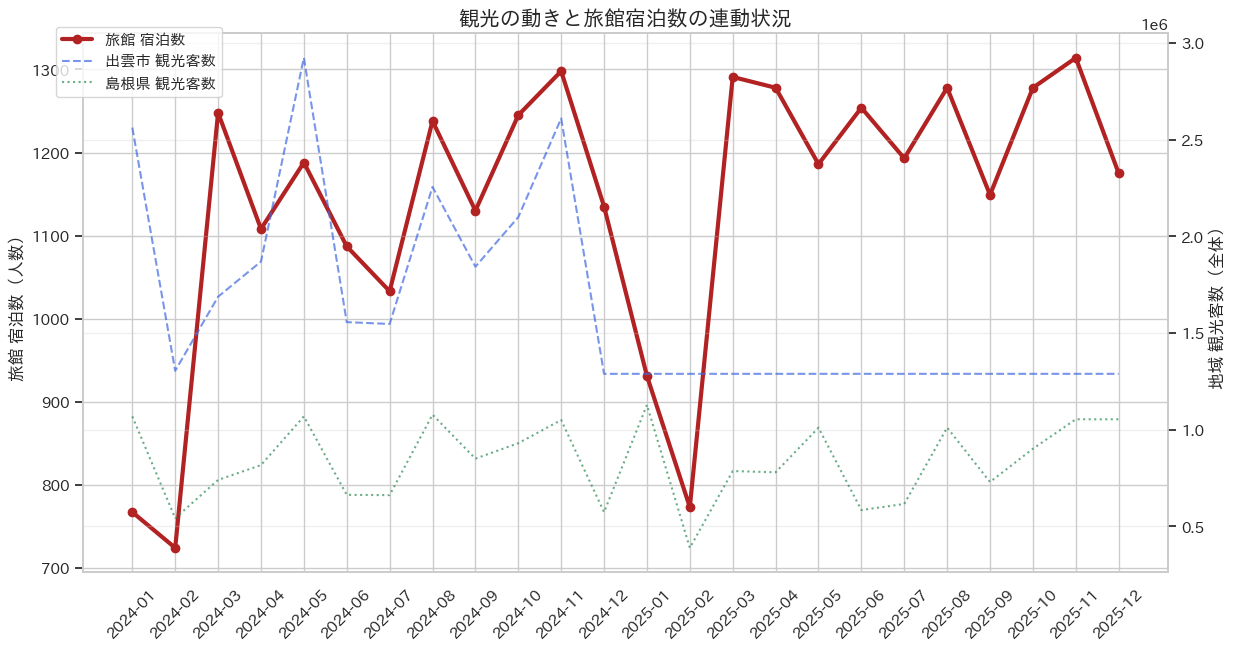

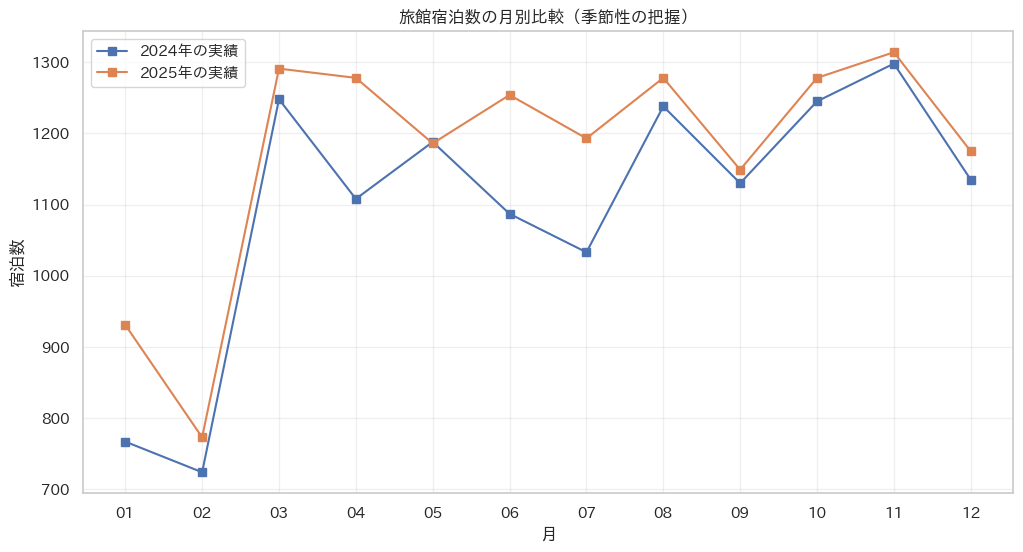

In [ ]:
# 1. 旅館の宿泊数と周辺観光客数の推移を比較
fig, ax1 = plt.subplots(figsize=(14, 7))

# 左側の軸：旅館の宿泊数（赤い丸印の線）
ax1.plot(df_merged_analysis['month'], df_merged_analysis['ryokan_stays'], label='旅館 宿泊数', color='firebrick', marker='o', linewidth=3)
ax1.set_ylabel('旅館 宿泊数（人数）', fontsize=12)
plt.xticks(rotation=45) # 日付が見やすいように斜めに回転

# 右側の軸：周辺地域の観光客数（点線）
ax2 = ax1.twinx()
ax2.plot(df_merged_analysis['month'], df_merged_analysis['izumo_visitors'], label='出雲市 観光客数', color='royalblue', linestyle='--', alpha=0.7)
ax2.plot(df_merged_analysis['month'], df_merged_analysis['shimane_visitors'], label='島根県 観光客数', color='seagreen', linestyle=':', alpha=0.7)
ax2.set_ylabel('地域 観光客数（全体）', fontsize=12)

plt.title('観光の動きと旅館宿泊数の連動状況', fontsize=15)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# 2. 「何月に人が増えるか」を年別に比較して季節性をチェック
plt.figure(figsize=(12, 6))
for target_year in df_merged_analysis['year_only'].unique():
    yearly_data = df_merged_analysis[df_merged_analysis['year_only'] == target_year]
    plt.plot(yearly_data['month_only'], yearly_data['ryokan_stays'], marker='s', label=f'{target_year}年の実績')

plt.title('旅館宿泊数の月別比較（季節性の把握）')
plt.xlabel('月')
plt.ylabel('宿泊数')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. 2026年予測・可視化（MVPフェーズ：未来予測）
- 過去の「月ごとの平均的な動き」をベースにして、2026年の宿泊人数を予測

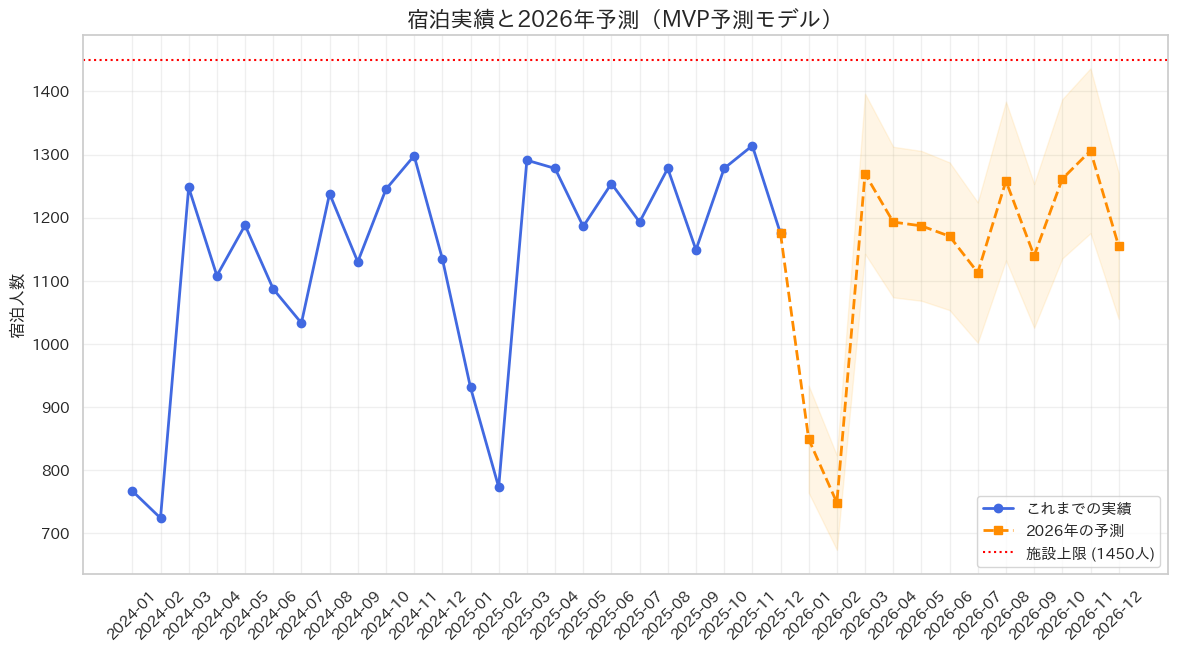

【2026年 月別宿泊数の予測一覧】


,年月,宿泊予測人数
0,2026-01,849.0人
1,2026-02,748.5人
2,2026-03,1269.5人
3,2026-04,1193.0人
4,2026-05,1187.0人
5,2026-06,1170.5人
6,2026-07,1113.0人
7,2026-08,1258.0人
8,2026-09,1139.5人
9,2026-10,1261.5人


In [ ]:
# 月ごとの平均（季節係数）を算出
average_seasonal_stays = df_merged_analysis.groupby('month_only')['ryokan_stays'].mean()

# 2026年の予測値を作成
df_forecast_2026 = pd.DataFrame({
    'month': [f"{PREDICTION_TARGET_YEAR}-{i:02d}" for i in range(1, 13)],
    'month_only': [f"{i:02d}" for i in range(1, 13)],
    'predicted_stays': average_seasonal_stays.values
})

# 施設の上限人数（キャパシティ）を超えないように調整
df_forecast_2026['predicted_stays'] = df_forecast_2026['predicted_stays'].clip(upper=MAX_CAPACITY_PER_MONTH)

# 実績データと予測データを一つのグラフに並べて表示
df_actual_plot = df_merged_analysis[['month', 'ryokan_stays']].copy()

plt.figure(figsize=(14, 7))

# 過去の実績（青い線）
plt.plot(df_actual_plot['month'], df_actual_plot['ryokan_stays'], marker='o', label='これまでの実績', color='royalblue', linewidth=2)

# 2026年の予測（オレンジの点線）
last_actual_point = df_actual_plot.iloc[-1:] # 実績の最後から予測を繋げる
df_forecast_conn = pd.concat([last_actual_point, df_forecast_2026.rename(columns={'predicted_stays': 'ryokan_stays'})])
plt.plot(df_forecast_conn['month'], df_forecast_conn['ryokan_stays'], marker='s', label=f'{PREDICTION_TARGET_YEAR}年の予測', color='darkorange', linestyle='--', linewidth=2)

# 施設の上限ラインを表示
plt.axhline(y=MAX_CAPACITY_PER_MONTH, color='red', linestyle=':', label=f'施設上限 ({MAX_CAPACITY_PER_MONTH}人)')

plt.title(f'宿泊実績と{PREDICTION_TARGET_YEAR}年予測（MVP予測モデル）', fontsize=16)
plt.ylabel('宿泊人数')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
# 予測には幅（誤差）があることを示すため、上下に10%の幅を描く
plt.fill_between(df_forecast_2026['month'], df_forecast_2026['predicted_stays'] * 0.9, df_forecast_2026['predicted_stays'] * 1.1, color='orange', alpha=0.1, label='予測の幅 (±10%)')
plt.show()

# 4. 2026年の予測値を表で表示
print(f"【{PREDICTION_TARGET_YEAR}年 月別宿泊数の予測一覧】")
forecast_table_display = df_forecast_2026[['month', 'predicted_stays']].rename(columns={'month': '年月', 'predicted_stays': '宿泊予測人数'})
display(forecast_table_display.style.format({'宿泊予測人数': '{:.1f}人'}))

# === ここまでがMVP（機械予測） ===